In [ ]:
A simple quadratic polynomial fit code (linear regression) using gradient descent

In [59]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [61]:
# generate a y = x^2 curve with x being uniform random using 6 points
# add small Gaussian errors in y, then make a plot
x = torch.rand((6))-0.5
y = x*x + 0.01*torch.randn_like(x)

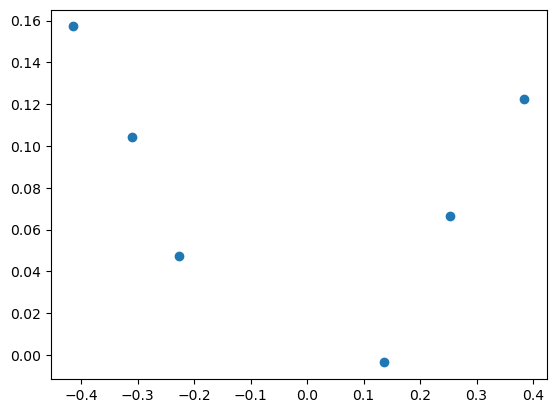

In [63]:
plt.scatter(x.numpy(), y.numpy(),marker='o')

In [65]:
# define the number of coefficients of the polynomial and 
# then set the fitting parameters in tensor w.  Since we need
# to compute d loss/dw, we must requires_grad.
# after that, we define a function fit().
n = 3
w = torch.randn((n), requires_grad=True)

def fit(x,w):
    yval = 0.0
    for i in range(len(w)):
        yval += w[i]*(x**i)
    return yval

In [67]:
# do the gradient descent.  It is necessary to reset the
# gradient to 0 after each iteration to avoid accumulation.
lr = 0.01
for epoch in range(2000):
    los = 0.0
    for j in range(len(x)):
        los += (y[j]-fit(x[j],w))**2
    los.backward()
    with torch.no_grad():
        w -= lr*w.grad
    w.grad.zero_()
print("los=",los,"weight",w)

los= tensor(0.0053, grad_fn=<AddBackward0>) weight tensor([ 0.0449, -0.0408,  0.3974], requires_grad=True)


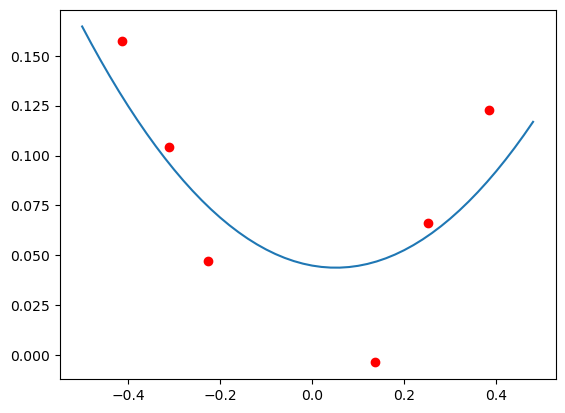

In [69]:
plt.scatter(x.numpy(), y.numpy(),marker='o',color='red')
xfit = np.arange(-0.5,0.5,0.02)
yfit = xfit.copy()
for i in range(len(xfit)):
    xval = xfit[i]
    yfit[i] = fit(xval,w).detach().numpy()
plt.plot(xfit,yfit)

In [ ]:
# compare with exact solution yhat = (X^T X)^(-1) X^T y.  
# I leave this as a student exercise to show that 
# gradient descent agrees with the exact formula.